# Forest Cover Type Classification

Luca Mongiello & Xiaojun Liang

Supervised multiclass classification of forest cover type (7 classes) on the UCI **Covertype** dataset (N = 581.012, p = 54), using Spark MLlib on a 2-node cluster (1 master + 1 worker), with data on **HDFS** and Spark running on **YARN**.

---

## Environment and required library versions

| Component   | Version |
|-------------|---------|
| Spark       | 4.1.2   |
| Hadoop      | 3.5.0   |
| Java        | 17      |
| Python      | 3.12.3  |
| pyspark     | 4.1.2   |
| pandas      | 3.0.5   |
| numpy       | 2.5.2   |
| matplotlib  | 3.11.1  |
| seaborn     | 0.13.2  |

## 1. Configuration

In [1]:
# --- Spark ---
SPARK_MASTER       = "yarn"
DEPLOY_MODE        = "client"
APP_NAME           = "covertype"
DRIVER_MEMORY      = "1g"        
EXECUTOR_INSTANCES = 1
EXECUTOR_CORES     = 4
EXECUTOR_MEMORY    = "6g"
EXECUTOR_OVERHEAD  = "1g"  
AM_MEMORY          = "512m"      
SHUFFLE_PARTITIONS = 8

# --- HDFS ---
HDFS_DIR  = "hdfs:///user/vagrant/covtype"
HDFS_RAW  = HDFS_DIR + "/covtype.data.gz"
LOCAL_RAW = "/home/vagrant/covtype.data.gz"
DATA_URL  = "https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz"

# --- Reproducibility and splits ---
SEED       = 42
TRAIN_FRAC = 0.8

In [2]:
# --- Imports ---
import os
import subprocess
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.stat import Correlation
from pyspark.ml.classification import (
    DecisionTreeClassifier, RandomForestClassifier,
    GBTClassifier, MultilayerPerceptronClassifier, OneVsRest,
)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

## 2. SparkSession

In [3]:
spark = (
    SparkSession.builder
    .appName(APP_NAME)
    .master(SPARK_MASTER)
    .config("spark.submit.deployMode",      DEPLOY_MODE)
    .config("spark.executor.instances",     EXECUTOR_INSTANCES)
    .config("spark.executor.cores",         EXECUTOR_CORES)
    .config("spark.executor.memory",        EXECUTOR_MEMORY)
    .config("spark.executor.memoryOverhead",EXECUTOR_OVERHEAD)
    .config("spark.yarn.am.memory",         AM_MEMORY)
    .config("spark.driver.memory",          DRIVER_MEMORY)
    .config("spark.sql.shuffle.partitions", SHUFFLE_PARTITIONS)
    .config("spark.ui.showConsoleProgress", "false")
    .config("spark.sql.debug.maxToStringFields", 100)
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/01 08:53:53 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/01 08:53:54 WARN Client: Neither spark.yarn.jars nor spark.yarn.archive is set, falling back to uploading libraries under SPARK_HOME.


## 3. Data acquisition

In [4]:
os.environ["HADOOP_ROOT_LOGGER"] = "ERROR,console"

def hdfs_exists(path: str) -> bool:
    return subprocess.run(["hdfs", "dfs", "-test", "-e", path]).returncode == 0

def sh(cmd: list):
    print("+", " ".join(cmd))
    subprocess.run(cmd, check=True)

if hdfs_exists(HDFS_RAW):
    print("Already on HDFS:", HDFS_RAW)
else:
    if not os.path.exists(LOCAL_RAW):
        print("Downloading:", DATA_URL)
        urllib.request.urlretrieve(DATA_URL, LOCAL_RAW)
        print("Saved to:", LOCAL_RAW)
    sh(["hdfs", "dfs", "-mkdir", "-p", HDFS_DIR])
    sh(["hdfs", "dfs", "-put", "-f", LOCAL_RAW, HDFS_RAW])
    print("Uploaded to HDFS:", HDFS_RAW)

sh(["hdfs", "dfs", "-ls", HDFS_DIR])

Already on HDFS: hdfs:///user/vagrant/covtype/covtype.data.gz
+ hdfs dfs -ls hdfs:///user/vagrant/covtype
Found 1 items
-rw-r--r--   1 vagrant supergroup   11240707 2026-08-31 13:21 hdfs:///user/vagrant/covtype/covtype.data.gz


## 4. Schema definition and data loading

In [5]:
# --- Column groups ---
QUANTITATIVE = [
    "Elevation",
    "Aspect",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am",
    "Hillshade_Noon",
    "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points",
]                                                             # 10 quantitative
WILDERNESS = [f"Wilderness_Area_{i}" for i in range(1, 5)]    # 4 binary
SOIL       = [f"Soil_Type_{i}"       for i in range(1, 41)]   # 40 binary
LABEL      = "Cover_Type"                                     # target (1..7)
CLASSES    = [f"C{i + 1}" for i in range(7)]                  # display labels

FEATURE_COLS = QUANTITATIVE + WILDERNESS + SOIL
ALL_COLS     = FEATURE_COLS + [LABEL]

schema = StructType([
    StructField(name, IntegerType()) for name in ALL_COLS
])

In [6]:
df = (
    spark.read
    .schema(schema)
    .option("header", "false")
    .csv(HDFS_RAW)
    .repartition(SHUFFLE_PARTITIONS)
    .cache()
)

print(f"Rows: {df.count():,}")

Rows: 581,012


In [7]:
df.printSchema()
df.select(QUANTITATIVE + [LABEL]).limit(5).toPandas()

root
 |-- Elevation: integer (nullable = true)
 |-- Aspect: integer (nullable = true)
 |-- Slope: integer (nullable = true)
 |-- Horizontal_Distance_To_Hydrology: integer (nullable = true)
 |-- Vertical_Distance_To_Hydrology: integer (nullable = true)
 |-- Horizontal_Distance_To_Roadways: integer (nullable = true)
 |-- Hillshade_9am: integer (nullable = true)
 |-- Hillshade_Noon: integer (nullable = true)
 |-- Hillshade_3pm: integer (nullable = true)
 |-- Horizontal_Distance_To_Fire_Points: integer (nullable = true)
 |-- Wilderness_Area_1: integer (nullable = true)
 |-- Wilderness_Area_2: integer (nullable = true)
 |-- Wilderness_Area_3: integer (nullable = true)
 |-- Wilderness_Area_4: integer (nullable = true)
 |-- Soil_Type_1: integer (nullable = true)
 |-- Soil_Type_2: integer (nullable = true)
 |-- Soil_Type_3: integer (nullable = true)
 |-- Soil_Type_4: integer (nullable = true)
 |-- Soil_Type_5: integer (nullable = true)
 |-- Soil_Type_6: integer (nullable = true)
 |-- Soil_Type

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type
0,3172,152,18,426,59,3521,239,237,120,3302,2
1,3211,41,14,268,14,5341,221,209,121,1253,1
2,2854,5,17,30,7,834,195,204,144,1878,2
3,3054,359,12,30,6,2604,202,219,153,834,1
4,2931,71,15,218,46,3483,236,210,102,2941,2


## 5. Exploratory Data Analysis

### 5.1 Class distribution and imbalance ratio

The target is strongly imbalanced. We quantify the imbalance ratio as $N_{max}/N_{min}$ over the full dataset.

Imbalance ratio (max/min): 103.1 : 1


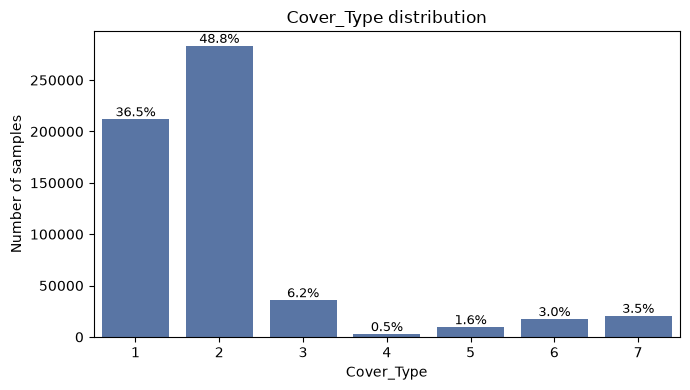

In [8]:
class_counts = (
    df.groupBy(LABEL).count()
      .orderBy(LABEL)
      .toPandas()
)
class_counts["pct"] = 100 * class_counts["count"] / class_counts["count"].sum()

imbalance_ratio = class_counts["count"].max() / class_counts["count"].min()
print(f"Imbalance ratio (max/min): {imbalance_ratio:.1f} : 1")

_, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=class_counts, x=LABEL, y="count", ax=ax, color="#4C72B0")
ax.set_title(f"Cover_Type distribution")
ax.set_xlabel("Cover_Type")
ax.set_ylabel("Number of samples")
for i, row in class_counts.iterrows():
    ax.text(i, row["count"], f"{row['pct']:.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### 5.2 Global descriptive statistics

In [9]:
global_stats = (
    df.select(QUANTITATIVE)
      .summary()
      .toPandas()
      .set_index("summary")
      .T
      .astype(float)
      .round(2)
)

global_stats

summary,count,mean,stddev,min,25%,50%,75%,max
Elevation,581012.0,2959.37,279.98,1859.0,2809.0,2996.0,3163.0,3858.0
Aspect,581012.0,155.66,111.91,0.0,58.0,127.0,260.0,360.0
Slope,581012.0,14.10,7.49,0.0,9.0,13.0,18.0,66.0
Horizontal_Distance_To_Hydrology,581012.0,269.43,212.55,0.0,108.0,218.0,384.0,1397.0
Vertical_Distance_To_Hydrology,581012.0,46.42,58.30,-173.0,7.0,30.0,69.0,601.0
Horizontal_Distance_To_Roadways,581012.0,2350.15,1559.25,0.0,1106.0,1997.0,3328.0,7117.0
Hillshade_9am,581012.0,212.15,26.77,0.0,198.0,218.0,231.0,254.0
Hillshade_Noon,581012.0,223.32,19.77,0.0,213.0,226.0,237.0,254.0
Hillshade_3pm,581012.0,142.53,38.27,0.0,119.0,143.0,168.0,254.0
Horizontal_Distance_To_Fire_Points,581012.0,1980.29,1324.20,0.0,1024.0,1710.0,2550.0,7173.0


### 5.3 Per-class statistics

We focus on `Elevation`, the most
discriminative feature according to Blackard & Dean (1999) and the feature-importance
analysis of Tavakol Sadrabadi & Innocente (2023): mean elevation separates several classes.

In [10]:
per_class_mean = (
    df.groupBy(LABEL)
      .agg(*[F.round(F.mean(c), 1).alias(c) for c in QUANTITATIVE])
      .orderBy(LABEL)
      .toPandas()
)

per_class_mean

,Cover_Type,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points
0,1,3128.6,156.1,13.1,270.6,42.2,2614.8,212.0,223.4,143.9,2009.3
1,2,2920.9,152.1,13.6,279.9,45.9,2429.5,213.8,225.3,143.0,2168.2
2,3,2394.5,176.4,20.8,210.3,62.4,943.9,201.9,215.8,140.4,911.0
3,4,2223.9,137.1,18.5,106.9,41.2,914.2,228.3,217.0,111.4,859.1
4,5,2787.4,139.3,16.6,212.4,50.6,1349.8,223.5,219.0,121.9,1577.7
5,6,2419.2,180.5,19.0,159.9,45.4,1037.2,192.8,209.8,148.3,1055.4
6,7,3361.9,153.2,14.3,357.0,69.5,2738.3,217.0,221.7,134.9,2070.0


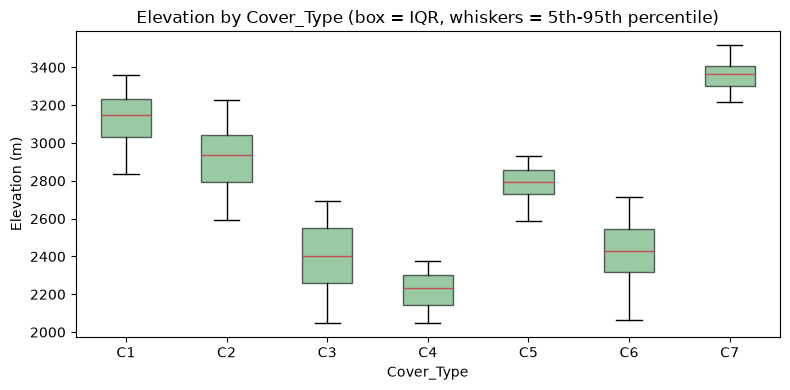

In [11]:
QS   = [0.05, 0.25, 0.5, 0.75, 0.95]
KEYS = ["whislo", "q1", "med", "q3", "whishi"]

elev_by_class = (
    df.groupBy(LABEL)
      .agg(F.percentile_approx("Elevation", QS).alias("q"))
      .orderBy(LABEL)
      .toPandas()
)

stats = [dict(zip(KEYS, r["q"]), label=CLASSES[r[LABEL] - 1])
         for _, r in elev_by_class.iterrows()]

_, ax = plt.subplots(figsize=(8, 4))
ax.bxp(stats, showfliers=False, patch_artist=True,
       boxprops={"facecolor": "#55A868", "alpha": 0.6},
       medianprops={"color": "#C44E52"})
ax.set_title("Elevation by Cover_Type (box = IQR, whiskers = 5th-95th percentile)")
ax.set_xlabel("Cover_Type")
ax.set_ylabel("Elevation (m)")
plt.tight_layout()
plt.show()

### 5.4 Correlation of quantitative features

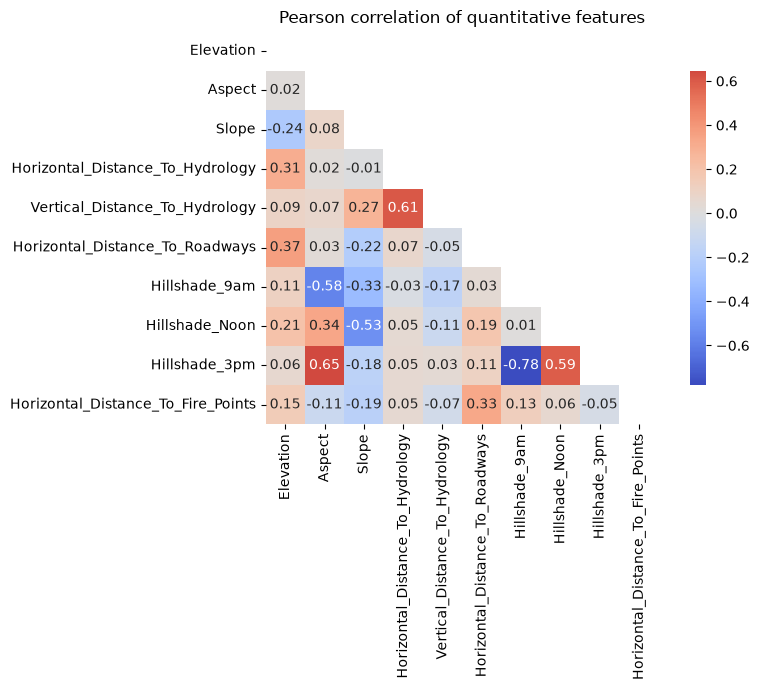

In [12]:
assembler = VectorAssembler(inputCols=QUANTITATIVE, outputCol="_quant_vec")
vec_df = assembler.transform(df.select(QUANTITATIVE))
corr_pd = pd.DataFrame(
    Correlation.corr(vec_df, "_quant_vec", "pearson").head()[0].toArray(),
    index=QUANTITATIVE, columns=QUANTITATIVE,
)

mask = np.triu(np.ones_like(corr_pd, dtype=bool))

_, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_pd, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Pearson correlation of quantitative features")
plt.tight_layout()
plt.show()

## 6. Preprocessing

In [13]:
df_ml = (
    VectorAssembler(inputCols=FEATURE_COLS, outputCol="features")
    .transform(df.withColumn("label", F.col(LABEL) - 1))
    .select("features", "label")
    .cache()
)

label_range = df_ml.agg(F.min("label"), F.max("label")).first()
print(f"Label range after remap: {label_range[0]}..{label_range[1]}")

df.unpersist();

Label range after remap: 0..6


In [14]:
train_df, test_df = df_ml.randomSplit([TRAIN_FRAC, 1 - TRAIN_FRAC], seed=SEED)
train_df.cache()
test_df.cache()

n_train = train_df.count()
n_test  = test_df.count()
print(f"Train rows: {n_train:,}")
print(f"Test  rows: {n_test:,}")

Train rows: 464,836
Test  rows: 116,176


In [15]:
counts = train_df.groupBy("label").count().toPandas().set_index("label")["count"]
min_count = int(counts.min())
print(f"Smallest training class: {min_count:,} rows")

undersample_fractions = {int(label): min_count / n for label, n in counts.items()}
train_bal = train_df.sampleBy("label", fractions=undersample_fractions, seed=SEED).cache()

bal_counts = train_bal.groupBy("label").count().orderBy("label").toPandas()
print(f"\nBalanced training rows: {bal_counts['count'].sum():,}")
print("Balanced training distribution:")
print(bal_counts.to_string(index=False))

df_ml.unpersist();

Smallest training class: 2,212 rows

Balanced training rows: 15,528
Balanced training distribution:
 label  count
     0   2276
     1   2213
     2   2210
     3   2212
     4   2265
     5   2106
     6   2246


## 7. Models

In [16]:
RESULTS = {}

def evaluate(name, model, test):
    n = len(CLASSES)
    cm_long = model.transform(test).groupBy("label", "prediction").count().toPandas()
    cm = (cm_long
          .pivot(index="label", columns="prediction", values="count")
          .reindex(index=range(n), columns=range(n))
          .fillna(0).astype(int))
    cm_v = cm.values.astype(float)

    tp = np.diag(cm_v)
    fp = cm_v.sum(axis=0) - tp
    fn = cm_v.sum(axis=1) - tp
    support = tp + fn
    with np.errstate(divide="ignore", invalid="ignore"):
        prec = np.nan_to_num(tp / (tp + fp))
        rec  = np.nan_to_num(tp / support)
        f1c  = np.nan_to_num(2 * prec * rec / (prec + rec))

    total = cm_v.sum()
    acc = tp.sum() / total
    f1w = (support * f1c).sum() / total

    per_class = pd.DataFrame(
        {"precision": prec.round(3), "recall": rec.round(3), "f1": f1c.round(3)},
        index=CLASSES,
    )

    RESULTS[name] = {"accuracy": acc, "weighted_f1": f1w,
                     "per_class": per_class, "cm": cm}

    print(f"{name}:  accuracy={acc:.4f}   weighted_F1={f1w:.4f}\n")
    print(per_class.to_string())

    cm_norm = cm_v / support.clip(min=1)[:, None]
    _, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES,
                ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title(f"{name} \u2014 normalized confusion matrix (row = true class)")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout(); plt.show()

In [17]:
MODELS = {
    "Decision Tree": DecisionTreeClassifier(
        labelCol="label", featuresCol="features", maxDepth=15, seed=SEED),

    "Random Forest": RandomForestClassifier(
        labelCol="label", featuresCol="features", numTrees=50, maxDepth=15, seed=SEED),

    "GBT": OneVsRest(
        labelCol="label", featuresCol="features",
        classifier=GBTClassifier(
            labelCol="label", featuresCol="features", maxIter=20, maxDepth=5, seed=SEED)),

    "MLP": Pipeline(stages=[
        StandardScaler(inputCol="features", outputCol="scaledFeatures",
                       withMean=True, withStd=True),
        MultilayerPerceptronClassifier(
            labelCol="label", featuresCol="scaledFeatures",
            layers=[len(FEATURE_COLS), 32, 7], maxIter=100, seed=SEED),
    ]),
}

## 8. Balanced training

Decision Tree (balanced):  accuracy=0.6593   weighted_F1=0.6746

    precision  recall     f1
C1      0.694   0.683  0.688
C2      0.781   0.591  0.673
C3      0.754   0.744  0.749
C4      0.531   0.907  0.669
C5      0.163   0.909  0.276
C6      0.487   0.795  0.604
C7      0.518   0.937  0.667


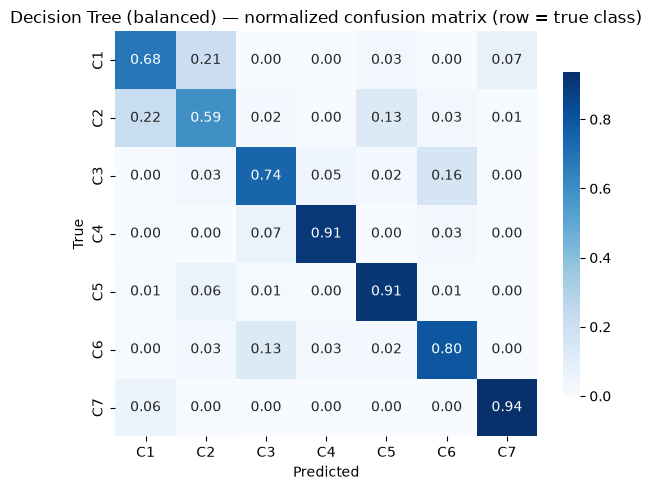

In [18]:
evaluate("Decision Tree (balanced)", MODELS["Decision Tree"].fit(train_bal), test_df)

Random Forest (balanced):  accuracy=0.6768   weighted_F1=0.6941

    precision  recall     f1
C1      0.708   0.740  0.724
C2      0.844   0.579  0.687
C3      0.751   0.756  0.754
C4      0.450   0.951  0.611
C5      0.160   0.933  0.273
C6      0.481   0.815  0.605
C7      0.502   0.953  0.658


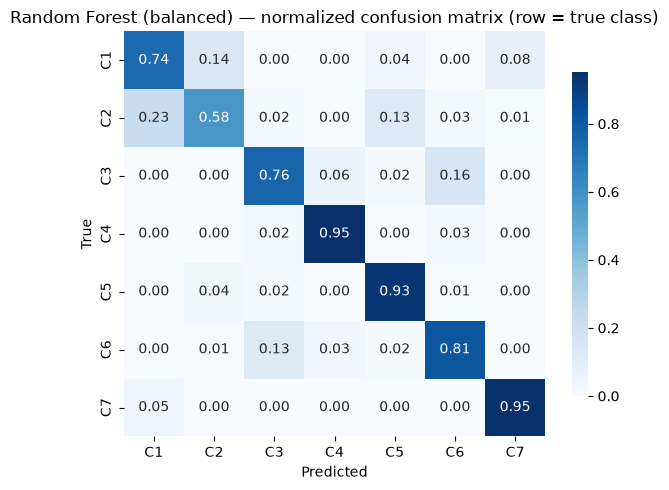

In [19]:
evaluate("Random Forest (balanced)", MODELS["Random Forest"].fit(train_bal), test_df)

GBT (balanced):  accuracy=0.6208   weighted_F1=0.6463

    precision  recall     f1
C1      0.689   0.687  0.688
C2      0.814   0.517  0.633
C3      0.726   0.697  0.711
C4      0.432   0.955  0.595
C5      0.116   0.901  0.206
C6      0.425   0.756  0.544
C7      0.422   0.938  0.583


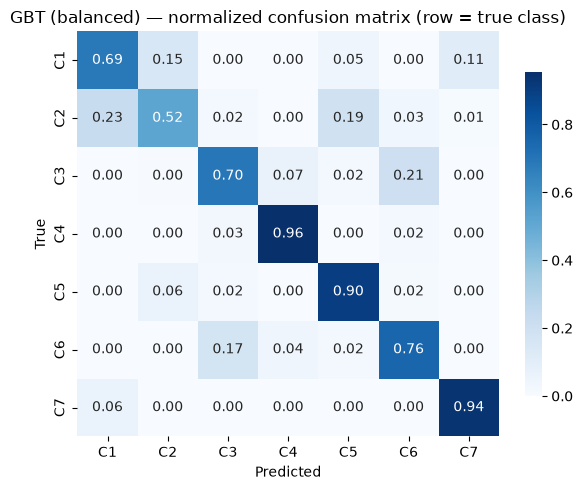

In [20]:
evaluate("GBT (balanced)", MODELS["GBT"].fit(train_bal), test_df)

MLP (balanced):  accuracy=0.6657   weighted_F1=0.6827

    precision  recall     f1
C1      0.708   0.702  0.705
C2      0.811   0.606  0.694
C3      0.699   0.679  0.689
C4      0.340   0.901  0.493
C5      0.170   0.879  0.286
C6      0.415   0.684  0.517
C7      0.481   0.940  0.637


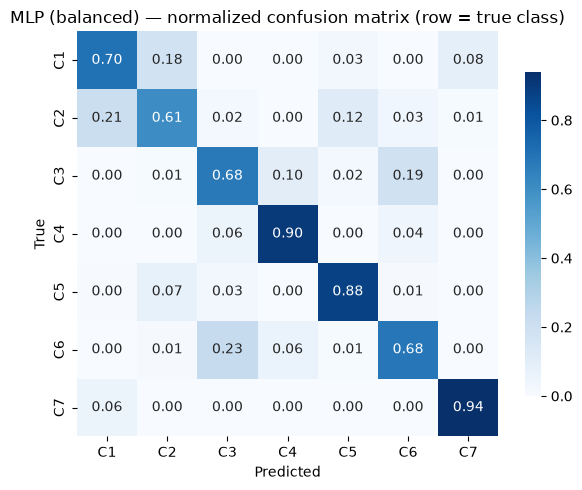

In [21]:
evaluate("MLP (balanced)", MODELS["MLP"].fit(train_bal), test_df)

## 9. Hyperparameter tuning

In [22]:
_eval_f1 = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1")

def tune_model(name, estimator, param_grid, train, test):
    cv = CrossValidator(
        estimator=estimator,
        estimatorParamMaps=param_grid,
        evaluator=_eval_f1,
        numFolds=3,
        parallelism=2,
        seed=SEED,
    )
    cv_model = cv.fit(train)

    metrics = cv_model.avgMetrics
    best_i = np.argmax(metrics) if _eval_f1.isLargerBetter() else np.argmin(metrics)
    best_params = cv_model.getEstimatorParamMaps()[best_i]

    best = ", ".join(f"{p.name}={v}" for p, v in best_params.items())
    print(f"{name} searched {len(param_grid)} param combo(s) x {cv.getNumFolds()} folds "
          f"-- best: {best}", flush=True)

    evaluate(name, cv_model.bestModel, test)

Decision Tree (tuned, balanced) searched 3 param combo(s) x 3 folds -- best: maxDepth=20
Decision Tree (tuned, balanced):  accuracy=0.6741   weighted_F1=0.6860

    precision  recall     f1
C1      0.695   0.691  0.693
C2      0.783   0.616  0.689
C3      0.749   0.757  0.753
C4      0.531   0.901  0.668
C5      0.190   0.899  0.314
C6      0.504   0.779  0.612
C7      0.540   0.933  0.684


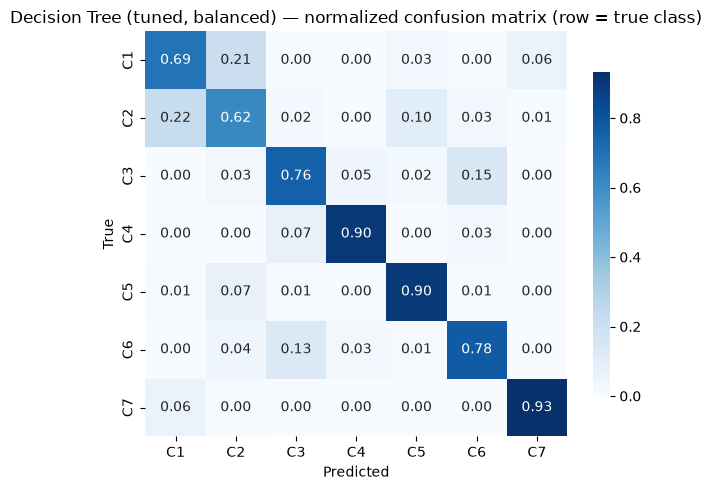

In [23]:
dt_grid = (ParamGridBuilder()
           .addGrid(MODELS["Decision Tree"].maxDepth, [10, 15, 20])
           .build())
tune_model("Decision Tree (tuned, balanced)", MODELS["Decision Tree"], dt_grid,
           train_bal, test_df)

Random Forest (tuned, balanced) searched 6 param combo(s) x 3 folds -- best: numTrees=100, maxDepth=25
Random Forest (tuned, balanced):  accuracy=0.7266   weighted_F1=0.7393

    precision  recall     f1
C1      0.750   0.757  0.754
C2      0.857   0.663  0.748
C3      0.759   0.786  0.772
C4      0.462   0.959  0.623
C5      0.215   0.935  0.350
C6      0.526   0.835  0.646
C7      0.537   0.959  0.688


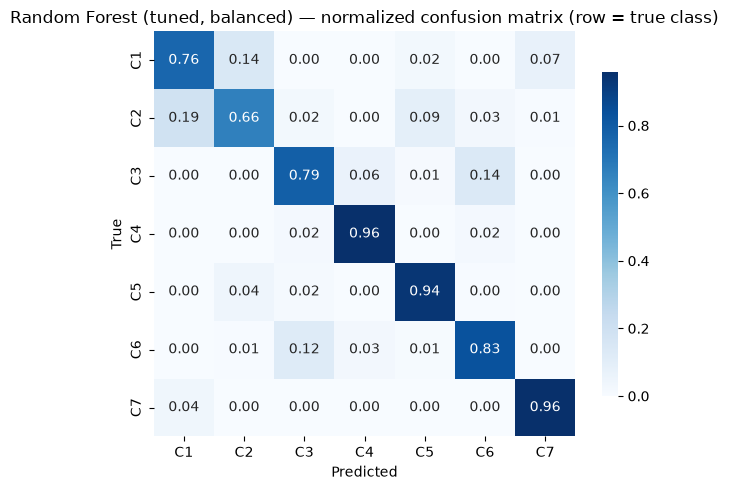

In [24]:
rf_grid = (ParamGridBuilder()
           .addGrid(MODELS["Random Forest"].numTrees, [50, 100])
           .addGrid(MODELS["Random Forest"].maxDepth, [15, 20, 25])
           .build())
tune_model("Random Forest (tuned, balanced)", MODELS["Random Forest"], rf_grid,
           train_bal, test_df)

GBT (tuned, balanced) searched 4 param combo(s) x 3 folds -- best: maxDepth=5, maxIter=20
GBT (tuned, balanced):  accuracy=0.6208   weighted_F1=0.6463

    precision  recall     f1
C1      0.689   0.687  0.688
C2      0.814   0.517  0.633
C3      0.726   0.697  0.711
C4      0.432   0.955  0.595
C5      0.116   0.901  0.206
C6      0.425   0.756  0.544
C7      0.422   0.938  0.583


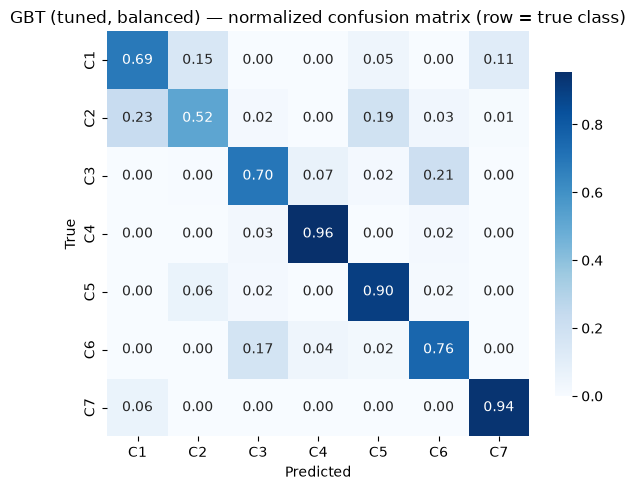

In [25]:
gbt_inner = MODELS["GBT"].getClassifier()
gbt_grid = (ParamGridBuilder()
            .addGrid(gbt_inner.maxDepth, [3, 5])
            .addGrid(gbt_inner.maxIter, [10, 20])
            .build())
tune_model("GBT (tuned, balanced)", MODELS["GBT"], gbt_grid, train_bal, test_df)

MLP (tuned, balanced) searched 4 param combo(s) x 3 folds -- best: layers=[54, 128, 64, 7], maxIter=300
MLP (tuned, balanced):  accuracy=0.7439   weighted_F1=0.7530

    precision  recall     f1
C1      0.759   0.751  0.755
C2      0.842   0.702  0.766
C3      0.798   0.794  0.796
C4      0.569   0.951  0.712
C5      0.259   0.937  0.406
C6      0.547   0.846  0.665
C7      0.574   0.954  0.717


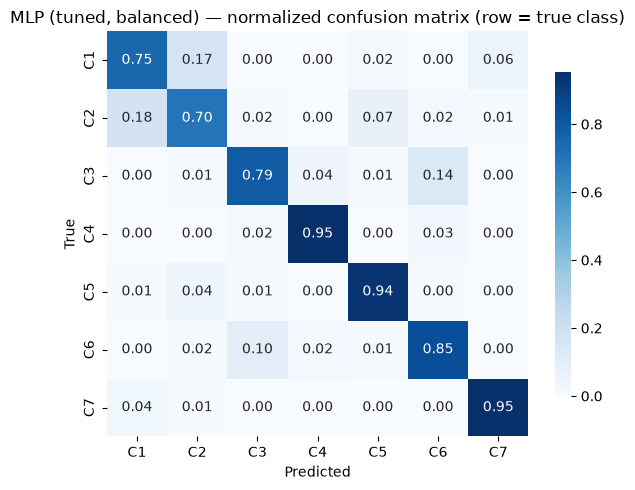

In [26]:
n_feat = len(FEATURE_COLS)
mlp_inner = MODELS["MLP"].getStages()[-1]
mlp_grid = (ParamGridBuilder()
            .addGrid(mlp_inner.layers, [[n_feat, 64, 32, 7], [n_feat, 128, 64, 7]])
            .addGrid(mlp_inner.maxIter, [200, 300])
            .build())
tune_model("MLP (tuned, balanced)", MODELS["MLP"], mlp_grid, train_bal, test_df)

## 10. Imbalanced training

Decision Tree (imbalanced):  accuracy=0.8508   weighted_F1=0.8483

    precision  recall     f1
C1      0.866   0.825  0.845
C2      0.841   0.905  0.872
C3      0.878   0.818  0.847
C4      0.871   0.705  0.779
C5      0.811   0.341  0.480
C6      0.715   0.627  0.668
C7      0.909   0.866  0.887


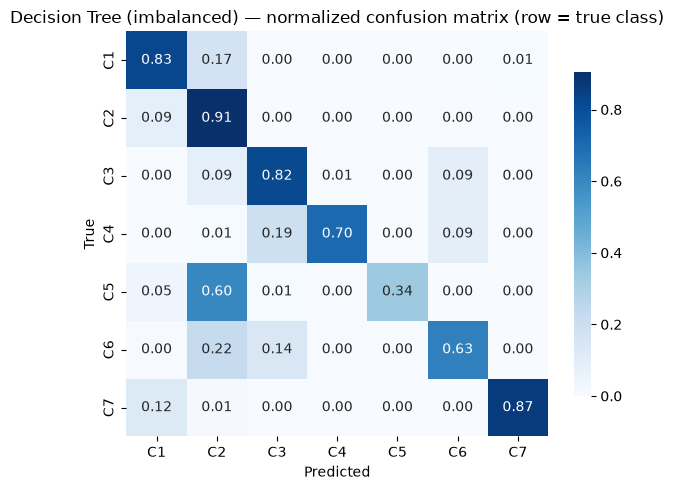

In [27]:
evaluate("Decision Tree (imbalanced)", MODELS["Decision Tree"].fit(train_df), test_df)

Random Forest (imbalanced):  accuracy=0.7905   weighted_F1=0.7825

    precision  recall     f1
C1      0.786   0.765  0.775
C2      0.786   0.857  0.820
C3      0.766   0.884  0.821
C4      0.898   0.645  0.751
C5      0.934   0.121  0.214
C6      0.910   0.321  0.474
C7      0.931   0.703  0.801


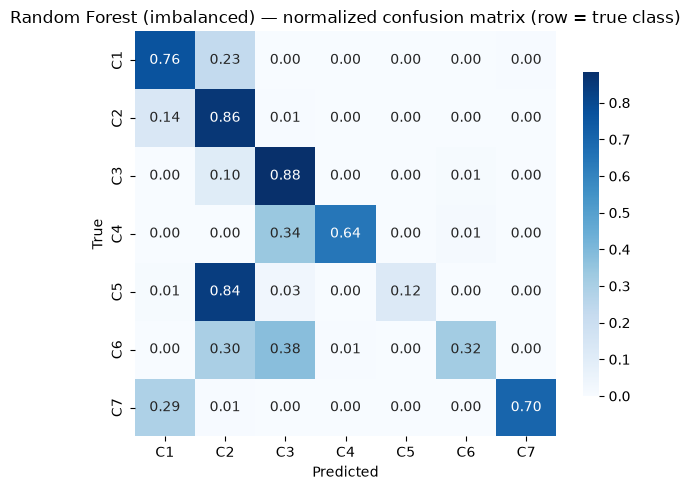

In [28]:
evaluate("Random Forest (imbalanced)", MODELS["Random Forest"].fit(train_df), test_df)

GBT (imbalanced):  accuracy=0.7646   weighted_F1=0.7579

    precision  recall     f1
C1      0.755   0.741  0.748
C2      0.776   0.829  0.801
C3      0.731   0.852  0.787
C4      0.832   0.686  0.752
C5      0.869   0.136  0.235
C6      0.615   0.340  0.438
C7      0.846   0.636  0.726


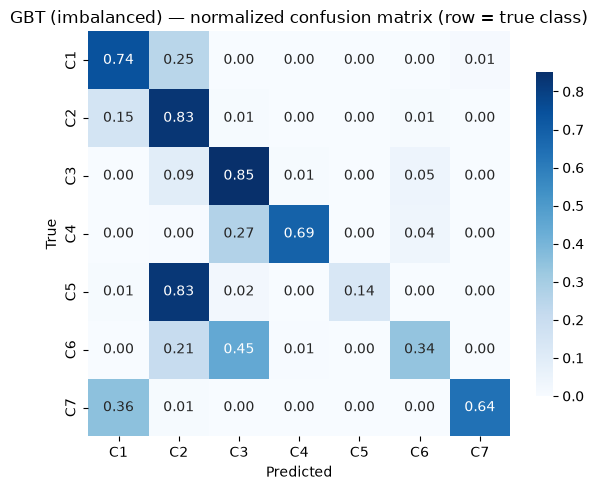

In [29]:
evaluate("GBT (imbalanced)", MODELS["GBT"].fit(train_df), test_df)

MLP (imbalanced):  accuracy=0.7846   weighted_F1=0.7795

    precision  recall     f1
C1      0.788   0.766  0.777
C2      0.803   0.846  0.824
C3      0.712   0.815  0.760
C4      0.557   0.329  0.414
C5      0.703   0.176  0.282
C6      0.554   0.410  0.471
C7      0.807   0.732  0.768


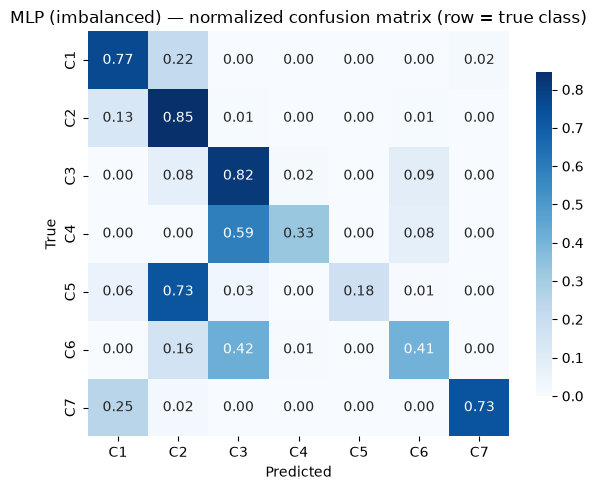

In [30]:
evaluate("MLP (imbalanced)", MODELS["MLP"].fit(train_df), test_df)

## 11. Results and Discussion

In [31]:
summary_full = pd.DataFrame({
    name: {
        "accuracy":        round(r["accuracy"], 3),
        "weighted_F1":     round(r["weighted_f1"], 3),
        "macro_precision": round(r["per_class"]["precision"].mean(), 3),
        "macro_recall":    round(r["per_class"]["recall"].mean(), 3),
    }
    for name, r in RESULTS.items()
}).T.sort_index()

summary_full

,accuracy,weighted_F1,macro_precision,macro_recall
Decision Tree (balanced),0.659,0.675,0.561,0.795
Decision Tree (imbalanced),0.851,0.848,0.842,0.727
"Decision Tree (tuned, balanced)",0.674,0.686,0.570,0.797
GBT (balanced),0.621,0.646,0.518,0.779
GBT (imbalanced),0.765,0.758,0.775,0.603
"GBT (tuned, balanced)",0.621,0.646,0.518,0.779
MLP (balanced),0.666,0.683,0.518,0.770
MLP (imbalanced),0.785,0.780,0.703,0.582
"MLP (tuned, balanced)",0.744,0.753,0.621,0.848
Random Forest (balanced),0.677,0.694,0.557,0.818


The discussion below covers only what explains the code above. The interpretation of the
results, the comparison with the literature and the limitations are developed in the project
presentation.

### Reading the summary table

All twelve runs are scored on the same untouched, imbalanced test set. Models must be compared
**within a training regime**, not across the whole table: one trained on the imbalanced set
faces a test set carrying the same skew, so it wins on any frequency-weighted metric almost by
construction. The Decision Tree trained on imbalanced data tops the study on both accuracy and
weighted F1, yet recovers barely a third of class 5 -- which is why every model above reports
per-class metrics and macro-averages next to accuracy rather than accuracy alone.

Among the balanced-trained models the tuned MLP is the best on both axes (weighted F1 0.753,
macro-recall 0.848), with the tuned Random Forest close behind (0.739 and 0.842). The two form a
clear leading pair, well ahead of the other families, but their margin is narrow enough that the
ordering between them should not be over-read. Both improved on *both* axes over their own
untuned baselines.

### The train/test split

The split is a uniform 80/20 `randomSplit`, which partitions the rows by construction and is
deterministic under recomputation. Stratifying it would change nothing measurable here: the
rarest class has 2,747 rows, so its expected share of the test set varies by about two
hundredths of a percentage point under uniform sampling -- smaller than the deviation an
approximate stratified sampler introduces anyway.

### Conclusion

Four model families, each trained on a balanced and an imbalanced training set and each tuned by
cross-validation, on Spark MLlib over HDFS and YARN. The central finding is methodological
rather than a single accuracy number: on a severely imbalanced dataset the class-balancing
strategy governs a direct trade-off between overall accuracy and minority-class recall, which
only per-class and macro-averaged metrics make visible.

## 12. Shutdown

In [32]:
spark.stop()